In [ ]:
!pip install jiwer
!pip install git+https://github.com/openai/whisper.git

In [ ]:
!pip install python-Levenshtein

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.4/177.4 kB 5.5 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from jiwer import wer, cer
import Levenshtein
from whisper import load_model


In [ ]:
import os

In [ ]:
# Încărcarea datelor din fișierul TSV
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/licenta/test.tsv', sep='\t', header=0, names=['path', 'sentence'])

# Definirea modelelor Whisper pe care dorim să le testăm
models = ['tiny','base', 'small', 'medium', 'large']
results = {model: {'WER': [], 'CER': [], 'levenshtein_ratio': []} for model in models}
cale_fisiere = "/content/drive/MyDrive/Colab Notebooks/licenta/horoscop_date/corecte"

In [ ]:
# Funcție pentru calculul ratelor și a scorurilor
def calculate_metrics(predicted, reference):
    wer_score = wer(reference, predicted)
    cer_score = cer(reference, predicted)
    levenshtein_ratio = Levenshtein.ratio(reference, predicted)
    return wer_score, cer_score, levenshtein_ratio

In [ ]:
df.iloc[0]

path                                               100_13.wav
sentence    Berbec. O să vă dați întâlnire cu cineva care ...
Name: 0, dtype: object

In [ ]:
for model_name in models:
    model = load_model(model_name, device="cuda")
    wer_scores = []
    cer_scores = []
    lev_scores = []

    for index, row in df.iterrows():
        reference_text = row['sentence']
        result = model.transcribe(os.path.join(cale_fisiere, row['path']), language="ro")
        predicted_text = result['text']
        wer_score, cer_score, levenshtein_ratio = calculate_metrics(predicted_text, reference_text)

        wer_scores.append(wer_score)
        cer_scores.append(cer_score)
        lev_scores.append(levenshtein_ratio)

    results[model_name]['WER'].append(sum(wer_scores)/len(wer_scores))
    results[model_name]['CER'].append(sum(cer_scores)/len(cer_scores))
    results[model_name]['levenshtein_ratio'].append(sum(lev_scores)/len(lev_scores))
    print(model_name, ":\n", results[model_name])

tiny :
 {'WER': [0.7949318865437667], 'CER': [0.34353384000038334], 'levenshtein_ratio': [0.7597333009544469]}
base :
 {'WER': [0.5978719352380543], 'CER': [0.22371453225704435], 'levenshtein_ratio': [0.8335649739019445]}
small :
 {'WER': [0.3986406919526626], 'CER': [0.1264005005743029], 'levenshtein_ratio': [0.9006729562070097]}


/usr/local/lib/python3.10/dist-packages/whisper/__init__.py:65: UserWarning: /root/.cache/whisper/medium.pt exists, but the SHA256 checksum does not match; re-downloading the file
  warnings.warn(
100%|█████████████████████████████████████| 1.42G/1.42G [00:56<00:00, 27.0MiB/s]


medium :
 {'WER': [0.2045635553557264], 'CER': [0.06610560317691626], 'levenshtein_ratio': [0.9459499584149924]}


100%|██████████████████████████████████████| 2.88G/2.88G [00:21<00:00, 144MiB/s]


large :
 {'WER': [0.12296051766966402], 'CER': [0.03516752742360843], 'levenshtein_ratio': [0.9687370638442591]}


In [ ]:
results

{'tiny': {'WER': [0.7949318865437667],
  'CER': [0.34353384000038334],
  'levenshtein_ratio': [0.7597333009544469]},
 'base': {'WER': [0.5978719352380543],
  'CER': [0.22371453225704435],
  'levenshtein_ratio': [0.8335649739019445]},
 'small': {'WER': [0.3986406919526626],
  'CER': [0.1264005005743029],
  'levenshtein_ratio': [0.9006729562070097]},
 'medium': {'WER': [0.2045635553557264],
  'CER': [0.06610560317691626],
  'levenshtein_ratio': [0.9459499584149924]},
 'large': {'WER': [0.12296051766966402],
  'CER': [0.03516752742360843],
  'levenshtein_ratio': [0.9687370638442591]}}

In [ ]:
wer_finetuned = {
    "tiny": 21.8545,
    "base": 17.0358,
    "small": 9.7834
}

In [ ]:
for model in models:
    print(results[model])

{'WER': [0.7949318865437667], 'CER': [0.34353384000038334], 'levenshtein_ratio': [0.7597333009544469]}
{'WER': [0.5978719352380543], 'CER': [0.22371453225704435], 'levenshtein_ratio': [0.8335649739019445]}
{'WER': [0.3986406919526626], 'CER': [0.1264005005743029], 'levenshtein_ratio': [0.9006729562070097]}
{'WER': [0.2045635553557264], 'CER': [0.06610560317691626], 'levenshtein_ratio': [0.9459499584149924]}
{'WER': [0.12296051766966402], 'CER': [0.03516752742360843], 'levenshtein_ratio': [0.9687370638442591]}


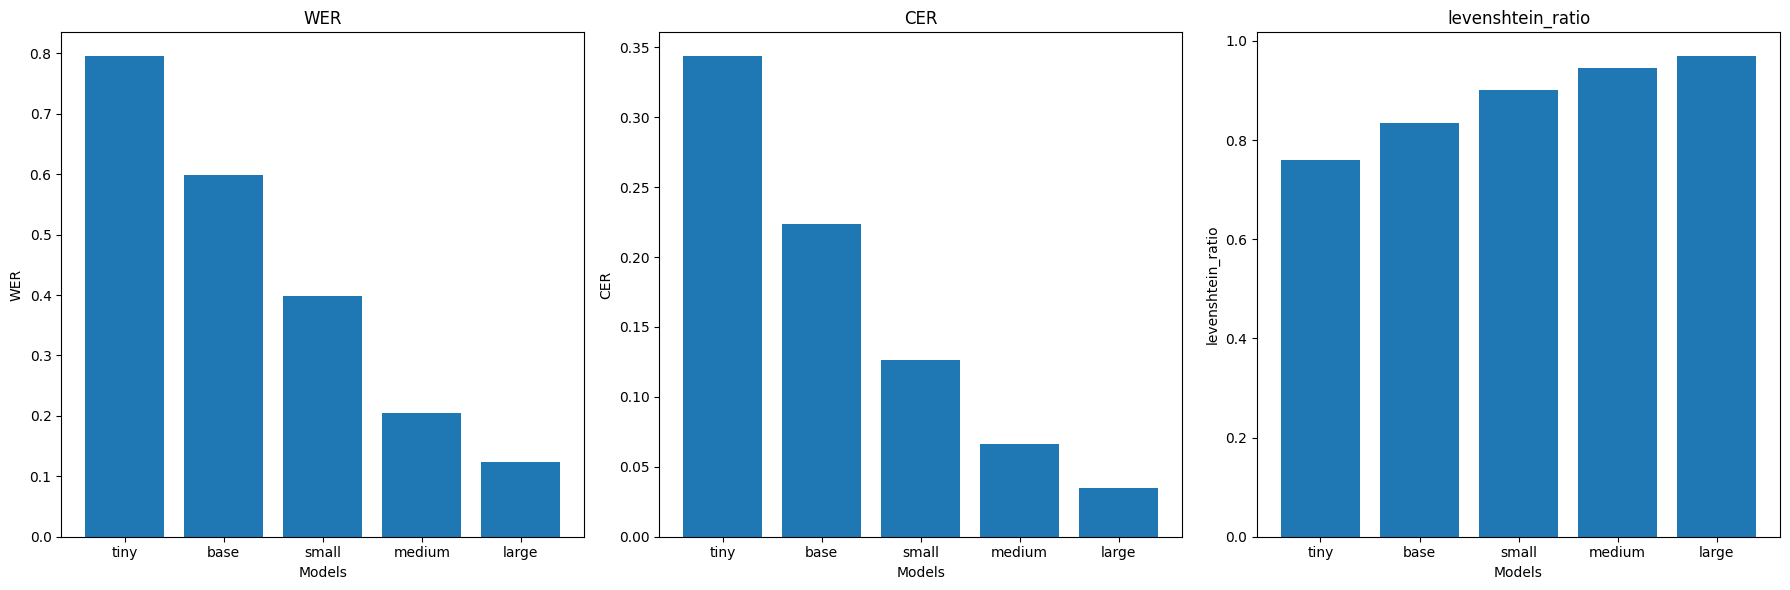

In [ ]:
import matplotlib.pyplot as plt

# Extragem numele modelelor
model_names = list(results.keys())

# Setăm dimensiunile graficului
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
metrics = ['WER', 'CER', 'levenshtein_ratio']

# Generăm fiecare grafic pentru metricile respective
for ax, metric in zip(axes, metrics):
    # Extragerea și plasarea valorilor medii pentru fiecare model pe grafic
    values = [results[model][metric][0] for model in model_names]  # Folosim indexul [0] pentru a accesa direct valoarea din listă
    ax.bar(model_names, values)
    ax.set_title(metric)
    ax.set_xlabel('Models')
    ax.set_ylabel(metric)

plt.tight_layout()
plt.show()


In [ ]:
# import matplotlib.pyplot as plt
# import numpy as np

# # Extragem numele modelelor
# model_names = list(results.keys())
# model_indices = np.arange(len(model_names))  # Creăm un set de indici pentru a plasa modelele pe axa X

# # Setăm dimensiunile graficului
# fig, axes = plt.subplots(1, 3, figsize=(18, 6))
# metrics = ['WER', 'CER', 'levenshtein_ratio']

# # Generăm fiecare grafic pentru metricile respective
# for ax, metric in zip(axes, metrics):
#     # Extragerea și plasarea valorilor medii pentru fiecare model ca puncte pe grafic
#     values = [results[model][metric][0] for model in model_names]  # Accesăm valoarea din listă
#     ax.scatter(model_indices, values, s=100)  # s controlează dimensiunea punctelor
#     ax.set_title(metric)
#     ax.set_xlabel('Models')
#     ax.set_ylabel(metric)
#     ax.set_xticks(model_indices)
#     ax.set_xticklabels(model_names)

# plt.tight_layout()
# plt.show()


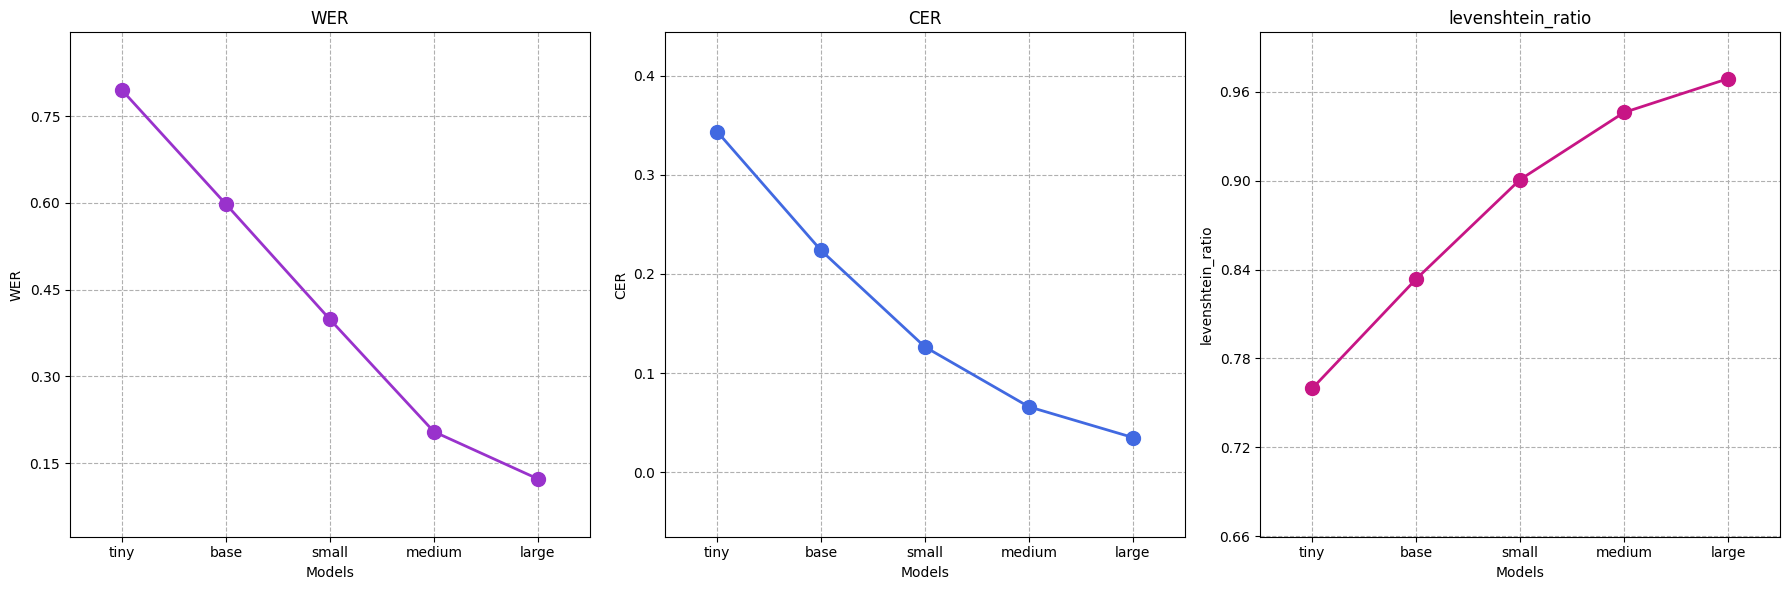

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import MaxNLocator

# Extragem numele modelelor și calculăm indicii
model_names = list(results.keys())
model_indices = np.arange(len(model_names))

# Setăm culorile pentru fiecare subplot
colors = ['darkorchid', 'royalblue', 'mediumvioletred']

# Setăm dimensiunile graficului
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
metrics = ['WER', 'CER', 'levenshtein_ratio']

max_values = {metric: max([results[model][metric][0] for model in model_names]) +0.1 for metric in metrics}
min_values = {metric: min([results[model][metric][0] for model in model_names]) -0.1 for metric in metrics}

# Generăm fiecare grafic pentru metricile respective
for ax, metric, color in zip(axes, metrics, colors):
    values = [results[model][metric][0] for model in model_names]
    ax.plot(model_indices, values, marker='o', color=color, linestyle='-', linewidth=2, markersize=10)
    ax.set_title(metric)
    ax.set_xlabel('Models')
    ax.set_ylabel(metric)
    ax.set_xticks(model_indices)
    ax.set_xticklabels(model_names)
    ax.set_ylim([min_values[metric], min(1, max_values[metric])])
    ax.set_xlim([model_indices[0] - 0.5, model_indices[-1] + 0.5])
    # ax.grid(True, axis="both", which="major")
    ax.yaxis.set_major_locator(MaxNLocator(6))
    ax.grid(True, which='major', axis='both', linestyle='--')

plt.tight_layout()
plt.show()


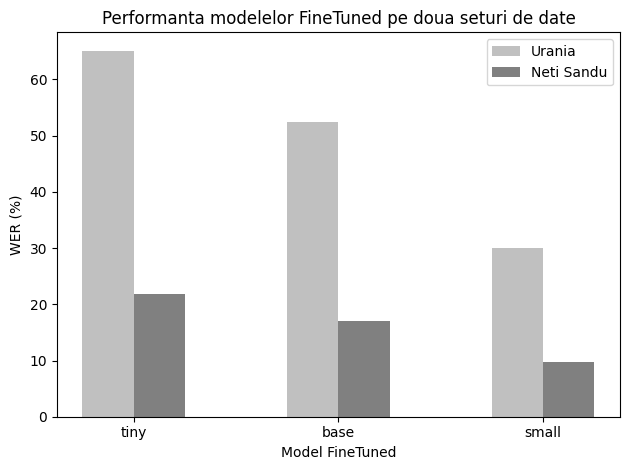

In [11]:
import matplotlib.pyplot as plt
import numpy as np

wer_finetuned_neti = {
    "tiny": 21.8545,
    "base": 17.0358,
    "small": 9.7834
}

results = {
    "tiny": {"WER": 72.53},
    "base": {"WER": 57.43},
    "small": {"WER": 33.99}
}

wer_finetuned = {
    "tiny": 65.13,
    "base": 52.49,
    "small": 29.98
}



# Selecția modelelor și a valorilor WER pentru comparare
model_ft = ['tiny', 'base', 'small']
wer_whisper = [results[model]['WER'] for model in model_ft]
wer_finetuned_values = [wer_finetuned[model] for model in model_ft]
wer_neti = [wer_finetuned_neti[model] for model in model_ft]

# Crearea graficului
index = np.arange(len(model_ft))
bar_width = 0.25

fig, ax = plt.subplots()
whisper_bars = ax.bar(index, wer_finetuned_values, bar_width, label='Urania', color='silver')
finetuned_bars = ax.bar(index + bar_width, wer_neti, bar_width, label='Neti Sandu', color='gray')

# Adăugarea de etichete, titlu și legenda axei
ax.set_xlabel('Model FineTuned')
ax.set_ylabel('WER (%)')
ax.set_title('Performanta modelelor FineTuned pe doua seturi de date')
ax.set_xticks(index + bar_width / 2)
ax.set_xticklabels(model_ft)
ax.legend()

plt.tight_layout()
plt.show()


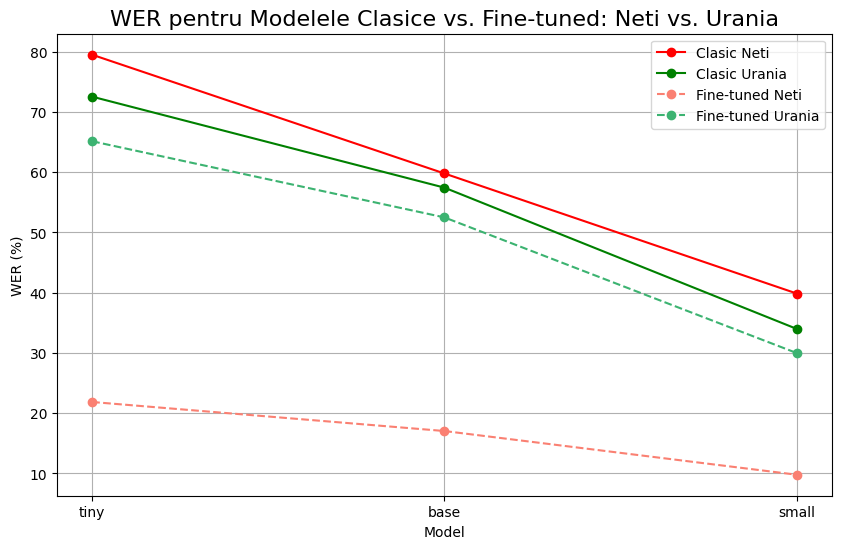

In [21]:
# Adjusting the graph based on the user's feedback
# - Adding markers to all lines to indicate values for each model.
# - Fine-tuned models will have dashed lines.
# - Changing title and legend to Romanian.
models = ['tiny', 'base', 'small']

# Accuracy and WER for Neti
wer_classic_neti = np.array([79.49, 59.78, 39.86])
wer_classic_urania = np.array([72.53, 57.43, 33.99])

# WER for fine-tuned Whisper models
wer_finetuned_neti_corrected = np.array([21.8545, 17.0358, 9.7834])
wer_finetuned_urania_corrected = np.array([65.13, 52.49, 29.98])


fig, ax = plt.subplots(figsize=(10, 6))

# Plotting classic models with continuous lines and markers
ax.plot(models, wer_classic_neti, color='red', marker='o', linestyle='-', label='Clasic Neti')
ax.plot(models, wer_classic_urania, color='green', marker='o', linestyle='-', label='Clasic Urania')

# Plotting fine-tuned models with dashed lines and markers
ax.plot(models, wer_finetuned_neti_corrected, color='salmon', marker='o', linestyle='--', label='Fine-tuned Neti')
ax.plot(models, wer_finetuned_urania_corrected, color='mediumseagreen', marker='o', linestyle='--', label='Fine-tuned Urania')

ax.set_xlabel('Model')
ax.set_ylabel('WER (%)')
ax.set_title('WER pentru Modelele Clasice vs. Fine-tuned: Neti vs. Urania', fontsize=16)
ax.legend()

plt.grid()
plt.show()
